In [2]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
import os

data_folder = '../data'
X = []
y = []

for file in os.listdir(data_folder):
    if file.endswith('.csv'):
        df = pd.read_csv(os.path.join(data_folder, file), header=None)
        vout= df[0].to_numpy()
        il = df[1].to_numpy()
        label = int(file.split('label_')[1].split('.')[0])
        waveform = np.stack([vout, il], axis=1)
        X.append(waveform)
        y.append(label)
min_len = min(len(x) for x in X) #finding the minimum length across all waveforms
X = np.array([x[:min_len] for x in X])#trimming to the same length
y = np.array(y)
X = X[:, ::1000, :]#downsampling the timesteps for conv1D and ESP32 controller
print(X.shape, y.shape)
    

(1500, 101, 2) (1500,)


In [4]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# encode labels for categorical crossentropy
y_train_cat = keras.utils.to_categorical(y_train, num_classes=3)
y_test_cat = keras.utils.to_categorical(y_test, num_classes=3)

print(X_train.shape, y_train_cat.shape)

(1200, 101, 2) (1200, 3)


In [5]:
model = Sequential([
   Conv1D(filters=16, kernel_size=8, activation='relu', input_shape=(101, 2), padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=4),
    
    Conv1D(filters=32, kernel_size=5, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=4),
    
    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),
    
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),           
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')
    ])

model.compile(optimizer='adam', 
              loss='categorical_crossentropy',
              metrics=['accuracy'] )

history = model.fit(
    X_train, y_train_cat,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test_cat)
)
print(history)
loss, accuracy = model.evaluate(X_test, y_test_cat)
print(f"Test accuracy: {accuracy:.4f}")


C:\Users\Administrator\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.8633 - loss: 0.3664 - val_accuracy: 0.3333 - val_loss: 1.3240
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9500 - loss: 0.1622 - val_accuracy: 0.3967 - val_loss: 0.9266
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9558 - loss: 0.1322 - val_accuracy: 0.5400 - val_loss: 0.7849
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9650 - loss: 0.1061 - val_accuracy: 0.7633 - val_loss: 0.5067
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9700 - loss: 0.0911 - val_accuracy: 0.9633 - val_loss: 0.1388
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9650 - loss: 0.1157 - val_accuracy: 0.9400 - val_loss: 0.1527
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9725 - loss: 0.0768 - val_accuracy: 0.8400 - val_loss: 0.3500
Epoch 8/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9758 - loss: 0.0868 - val_accuracy: 0.9800 - 

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step


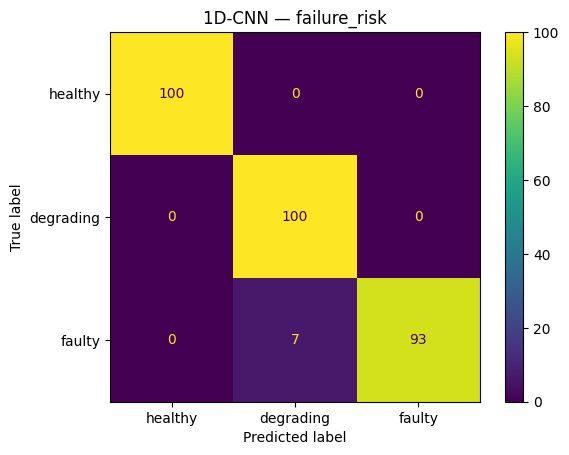

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_classes = np.argmax(model.predict(X_test), axis=1)
y_test_classes = np.argmax(y_test_cat, axis=1)
ConfusionMatrixDisplay.from_predictions(
    y_test_classes, y_pred_classes,
    display_labels=['healthy', 'degrading', 'faulty']
)
plt.title("1D-CNN — failure_risk")
plt.show()

In [7]:
model.save('../ml/cnn_model.keras')

In [10]:
import tensorflow as tf

model = tf.keras.models.load_model('../ml/cnn_model.keras')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('../ml/model.tflite', 'wb') as f:
    f.write(tflite_model)

print(f"Model size: {len(tflite_model)} bytes")

INFO:tensorflow:Assets written to: C:\Users\ADMINI~1\AppData\Local\Temp\tmp4003fbgt\assets


INFO:tensorflow:Assets written to: C:\Users\ADMINI~1\AppData\Local\Temp\tmp4003fbgt\assets


Saved artifact at 'C:\Users\ADMINI~1\AppData\Local\Temp\tmp4003fbgt'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 101, 2), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  1907078248400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907078249936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907078248592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907078249552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907078250128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907078249360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907078248976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907078250320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907078248784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907079070928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  19070782

In [11]:
def representative_dataset():
    for i in range(100):
        sample = X_train[i:i+1].astype(np.float32)
        yield [sample]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_quant_model = converter.convert()

with open('../ml/model_quant.tflite', 'wb') as f:
    f.write(tflite_quant_model)

print(f"Quantized model size: {len(tflite_quant_model)} bytes")

INFO:tensorflow:Assets written to: C:\Users\ADMINI~1\AppData\Local\Temp\tmp7sgkzjvn\assets


INFO:tensorflow:Assets written to: C:\Users\ADMINI~1\AppData\Local\Temp\tmp7sgkzjvn\assets


Saved artifact at 'C:\Users\ADMINI~1\AppData\Local\Temp\tmp7sgkzjvn'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 101, 2), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  1907078248400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907078249936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907078248592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907078249552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907078250128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907078249360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907078248976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907078250320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907078248784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1907079070928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  19070782

C:\Users\Administrator\AppData\Local\Programs\Python\Python311\Lib\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Quantized model size: 42584 bytes


In [12]:
with open('../ml/model_quant.tflite', 'rb') as f:
    tflite_bytes = f.read()

c_array = ', '.join([f'0x{b:02x}' for b in tflite_bytes])

c_code = f"""
#ifndef MODEL_H
#define MODEL_H

const unsigned char model_tflite[] = {{
  {c_array}
}};
const int model_tflite_len = {len(tflite_bytes)};

#endif
"""

with open('../firmware/src/model.h', 'w') as f:
    f.write(c_code)

print("model.h generated successfully")

FileNotFoundError: [Errno 2] No such file or directory: '../firmware/src/model.h'